In [18]:
import sys
!{sys.executable} -m pip install matplotlib scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

=============================================================
STEP 1: LOAD DATA & SELECT FEATURES
=============================================================
We pick only numeric columns that are meaningful for clustering.
KMeans is distance-based, so we want features that reflect
customer/order behavior — not IDs or zip codes.

In [30]:
df = pd.read_csv('../data/olist_cleaned.csv')
features = [
    'price',
    'freight_value', 
    'payment_installments',
    'review_score',
    'estimated_delivery_days',
]

X = df[features].values


=============================================================
STEP 2: SCALE THE FEATURES
=============================================================
KMeans calculates distances between points. If one feature is
in the thousands (e.g. product_weight_g) and another is 1–5
(review_score), the large feature will dominate the clustering.
StandardScaler transforms every feature to have:
- mean = 0
- standard deviation = 1
This puts all features on equal footing.

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

=============================================================
STEP 3: FIND THE BEST K USING A SAMPLE
=============================================================
Running the elbow/silhouette method on all 117k rows would be
slow. Instead, we randomly sample 20k rows — large enough to
represent the full dataset, fast enough to test many k values.
Then we can plot both metrics side by side to help choose k

In [32]:
sample_idx = np.random.choice(len(X_scaled), size=20_000, replace=False)
sample = X_scaled[sample_idx]

k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    labels = km.fit_predict(sample)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(sample, labels))


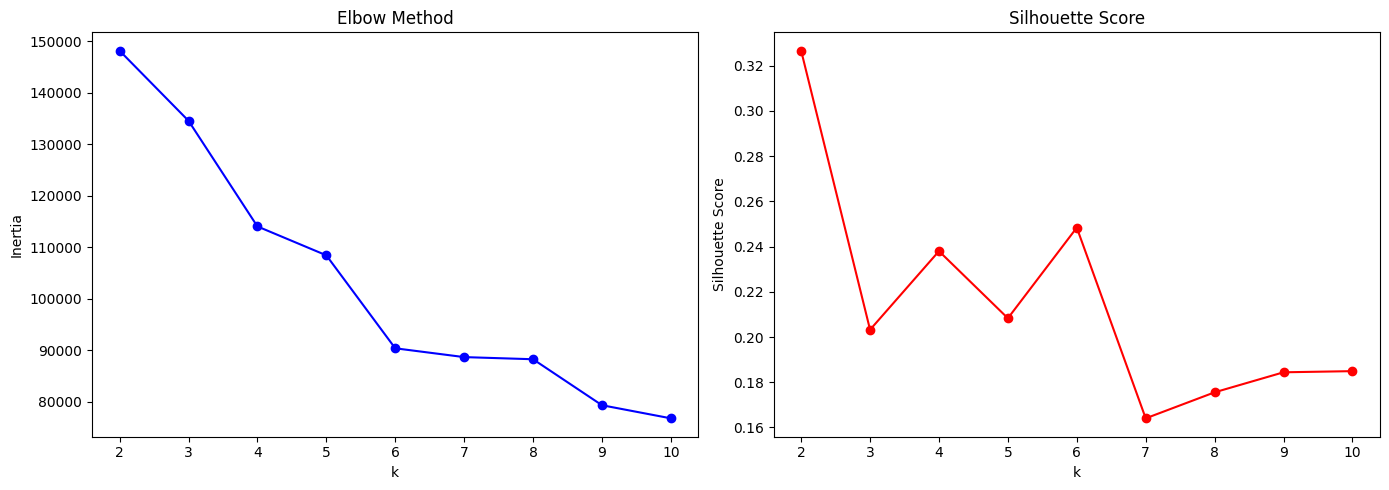

Best k by silhouette: 2


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, sil_scores, 'ro-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k by silhouette: {best_k}")

=============================================================
STEP 4: FIT THE FINAL MODEL ON THE FULL DATASET
=============================================================
Now that we know the best k, we train on all 117k rows.
MiniBatchKMeans trains on small random batches instead of the
full dataset at once — much faster, nearly identical results.

In [ ]:
model = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=2048,  
    random_state=42,
    n_init=3
)
model.fit(X_scaled)

df['cluster'] = model.labels_

=============================================================
STEP 5: PROFILE THE CLUSTERS
=============================================================
We group by cluster and look at the average value of each feature.
e.g. Cluster 0 might be "high price, low review score"
Cluster 1 might be "cheap items, fast delivery, happy customers"

In [ ]:
print("\nCluster profiles (mean values per feature):")
print(df.groupby('cluster')[features].mean().round(2).T)


Cluster profiles (mean values per feature):
cluster                        0        1
price                      75.66   260.49
freight_value              16.02    32.53
payment_installments        1.94     6.07
payment_value             106.55   376.45
review_score                4.19     3.53
estimated_delivery_days    22.44    26.80
product_weight_g         1104.62  5248.64
product_photos_qty          2.13     2.36


=============================================================
STEP 6: VISUALIZE WITH PCA
=============================================================
We have 8 features, which can't be plotted directly.
PCA (Principal Component Analysis) compresses those 8 dimensions down to 2, preserving as much structure as possible, so we can plot the clusters on a 2D scatter plot.
Note: we only plot 20k points for speed — the model itself used all data.

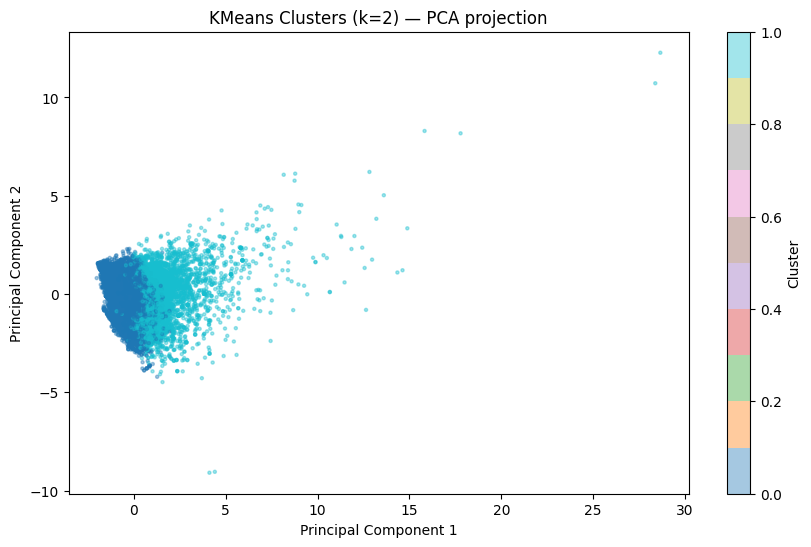

In [ ]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled[:20_000])
labels_2d = model.labels_[:20_000] 

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
       X_2d[:, 0], X_2d[:, 1],
       c=labels_2d, cmap='tab10',
       alpha=0.3, s=5,
       vmin=0, vmax=best_k - 1  # force discrete range
   )
plt.colorbar(scatter, label='Cluster', ticks=range(best_k))
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans Clusters (k={best_k}) — PCA projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()